# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

### Dataset

In [107]:
df = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


### Task #1: Visualization and 1st step toward the CAPM

#### Daily returns

In [108]:
daily_returns = df.pct_change()
daily_returns = daily_returns.iloc[1:]
daily_returns.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.003749,-0.012051,-0.001660,0.018137,0.014153,-0.007699,-0.193274,-0.007385,-0.004948
2012-01-17,0.011648,0.008579,0.005986,-0.008097,0.018159,0.004689,0.167179,0.005744,0.003553
2012-01-18,0.010384,-0.002392,0.002645,0.039184,0.042827,0.005944,0.007895,0.006889,0.011108
2012-01-19,-0.003169,0.006661,0.002967,0.005499,0.026446,-0.003038,-0.001865,0.010523,0.004939
2012-01-20,-0.017417,-0.000529,0.002959,-0.012500,-0.018102,0.044316,-0.005979,-0.083775,0.000669


#### Scatter Plots of daily returns against the market daily returns

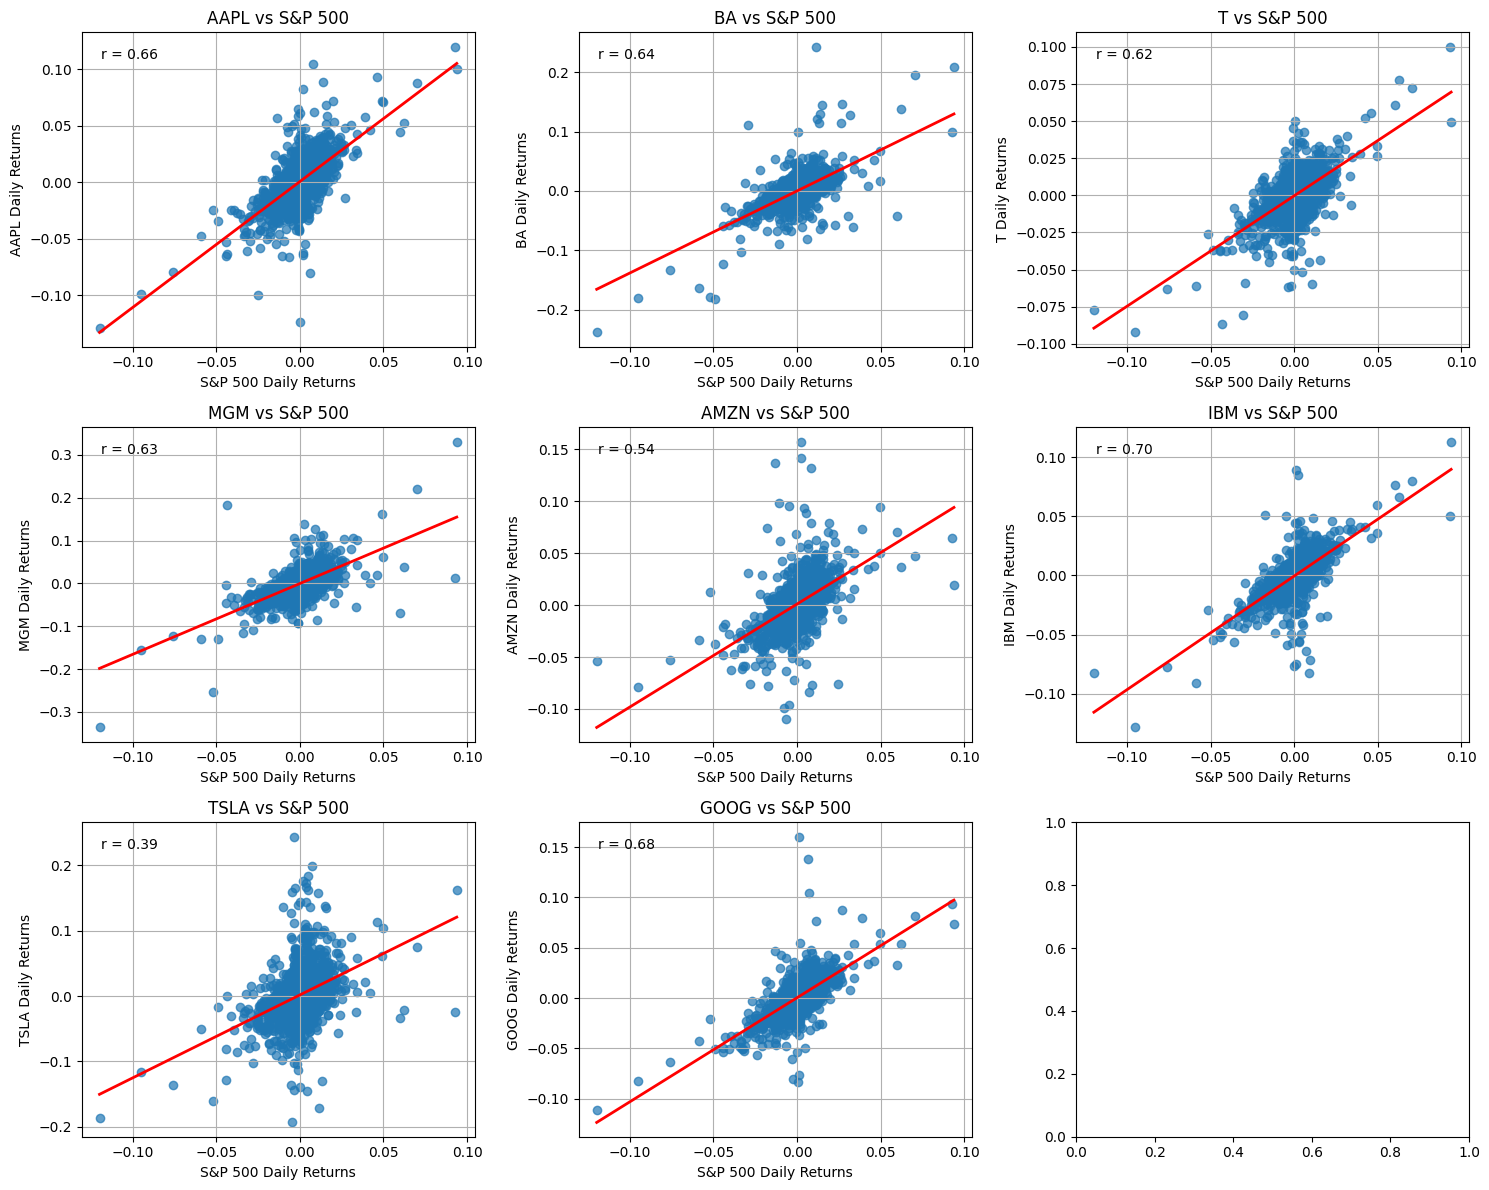

In [109]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(daily_returns.columns):
    if col != "sp500":
        ax = axes[i]

        x = daily_returns["sp500"].to_numpy(dtype=float)
        y = daily_returns[col].to_numpy(dtype=float)

        # scatter
        ax.scatter(x, y, alpha=0.7)

        if x.size >= 2 and np.ptp(x) > 0:
            # regression line
            m, b = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, m * x_line + b, color="red", linewidth=2)

            # correlation coefficient
            r = np.corrcoef(x, y)[0, 1]
            ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
                    fontsize=10, verticalalignment="top")

        ax.set_xlabel("S&P 500 Daily Returns")
        ax.set_ylabel(f"{col} Daily Returns")
        ax.set_title(f"{col} vs S&P 500")
        ax.grid(True)

plt.tight_layout()
plt.show()

For the majority of the stocks, the correlation of the daily returns with the benchmark (S&P 500) is relatively strong, especially for Google, Apple and IBM where the correlation is greater than 0.65.

The above-mentioned companies play a crucial role in the S&P 500 index, therefore changes in returns for each of the stocks individually, impact the changes of the market daily returns.

### Task #2: Compute alpha and beta

#### Apply the CAPM : run an OLS regression of stock i returns on market returns, over the whole period. Assume rf = 0. Are the estimates significant?

In [110]:
market = daily_returns["sp500"]
stocks = [c for c in daily_returns.columns if c != "sp500"]

rows = []
residuals = {}

for s in stocks:
    y = daily_returns[s].astype(float).to_numpy()
    X = sm.add_constant(market.astype(float).to_numpy())
    model = sm.OLS(y, X, missing="drop").fit()

    rows.append({
        "stock": s,
        "alpha": model.params[0],
        "beta": model.params[1],
        "t(alpha)": model.tvalues[0],
        "p(alpha)": model.pvalues[0],
        "t(beta)": model.tvalues[1],
        "p(beta)": model.pvalues[1],
        "R2": model.rsquared,
        "nobs": int(model.nobs)
    })

    residuals[s] = model.resid

summary = pd.DataFrame(rows).set_index("stock").sort_values("beta", ascending=False)
summary.round(4)


,alpha,beta,t(alpha),p(alpha),t(beta),p(beta),R2,nobs
stock,,,,,,,,
MGM,-0.0002,1.6536,-0.3679,0.7130,37.8118,0.0,0.3987,2158
BA,-0.0000,1.3829,-0.0613,0.9511,38.8625,0.0,0.4119,2158
TSLA,0.0018,1.2686,2.5809,0.0099,19.5425,0.0,0.1505,2158
AAPL,0.0005,1.1129,1.8312,0.0672,40.4999,0.0,0.4321,2158
GOOG,0.0003,1.0349,1.3392,0.1807,43.6062,0.0,0.4686,2158
AMZN,0.0010,0.9917,2.9222,0.0035,29.7563,0.0,0.2911,2158
IBM,-0.0005,0.9604,-2.4405,0.0147,46.0190,0.0,0.4955,2158
T,-0.0003,0.7446,-1.3322,0.1829,36.4486,0.0,0.3813,2158


- **Betas (β):**
  - All stocks have **highly significant β (p < 0.001)** → market returns strongly explain stock returns.  
  - MGM (1.65) and BA (1.38) are **riskier than the market** (β > 1).  
  - AAPL (1.11) and GOOG (1.03) are close to market risk (β ≈ 1).  
  - IBM (0.96) and T (0.74) are **defensive stocks**, less sensitive to the market.  

- **Alphas (α):**
  - TSLA (0.176, p = 0.0099) and AMZN (0.102%, p = 0.0035) have **positive and significant α** → they delivered returns beyond what CAPM predicts.  
  - IBM (-0.0535, p = 0.0147) has a **negative and significant α** → underperformance relative to CAPM expectations.  
  - AAPL and GOOG have **positive but insignificant α** → not statistically different from zero.  
  - MGM, BA, T have α ≈ 0 and **insignificant** → consistent with CAPM’s assumption that alpha = 0

- **R² (goodness of fit):**
  - Highest for IBM (0.495), GOOG (0.468), AAPL (0.432) → **well explained by the market**.  
  - Lowest for TSLA (0.150) → **most idiosyncratic risk**, confirming that Tesla’s daily return variance is weakly explained by the market alone.  

**Comment:**  
Statistical tests reinforce the CAPM intuition: β is always significant and measures systematic risk, while α should be ≈ 0. Deviations (TSLA, AMZN, IBM) may reflect either real mispricing or omitted risk factors.


#### Plot the beta and alpha for the 8 stocks. Which stock has the highest (lowest) beta and alpha? Comment!

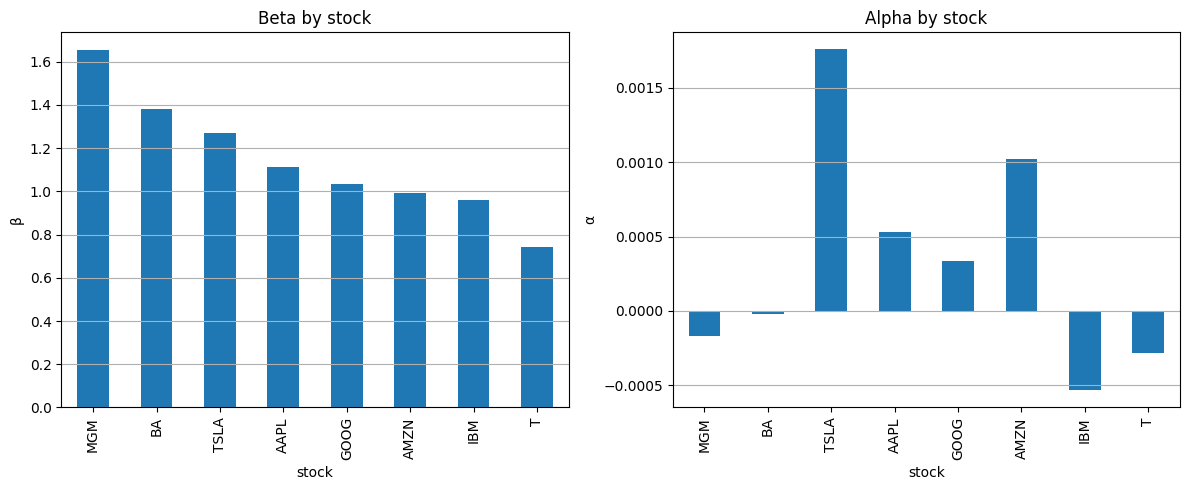

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

summary["beta"].plot(kind="bar", ax=ax[0])
ax[0].set_title("Beta by stock")
ax[0].set_ylabel("β")
ax[0].grid(True, axis="y")

summary["alpha"].plot(kind="bar", ax=ax[1])
ax[1].set_title("Alpha by stock")
ax[1].set_ylabel("α")
ax[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

- **Beta chart:** 
  - High-β stocks (MGM, BA) are **cyclical** and **react strongly to market conditions**.  
  - Low-β stocks (IBM, T) are more **defensive**.  

- **Alpha chart:**  
  - TSLA is a clear outlier with a large positive α, suggesting **persistent outperformance**.  
  - AMZN also shows positive α.  
  - IBM exhibits **negative α**, i.e. underperformance relative to CAPM expectations.  


#### Use the observed returns and the predicted ones to compute and plot the histogram of error terms εi for each stock. Comment!

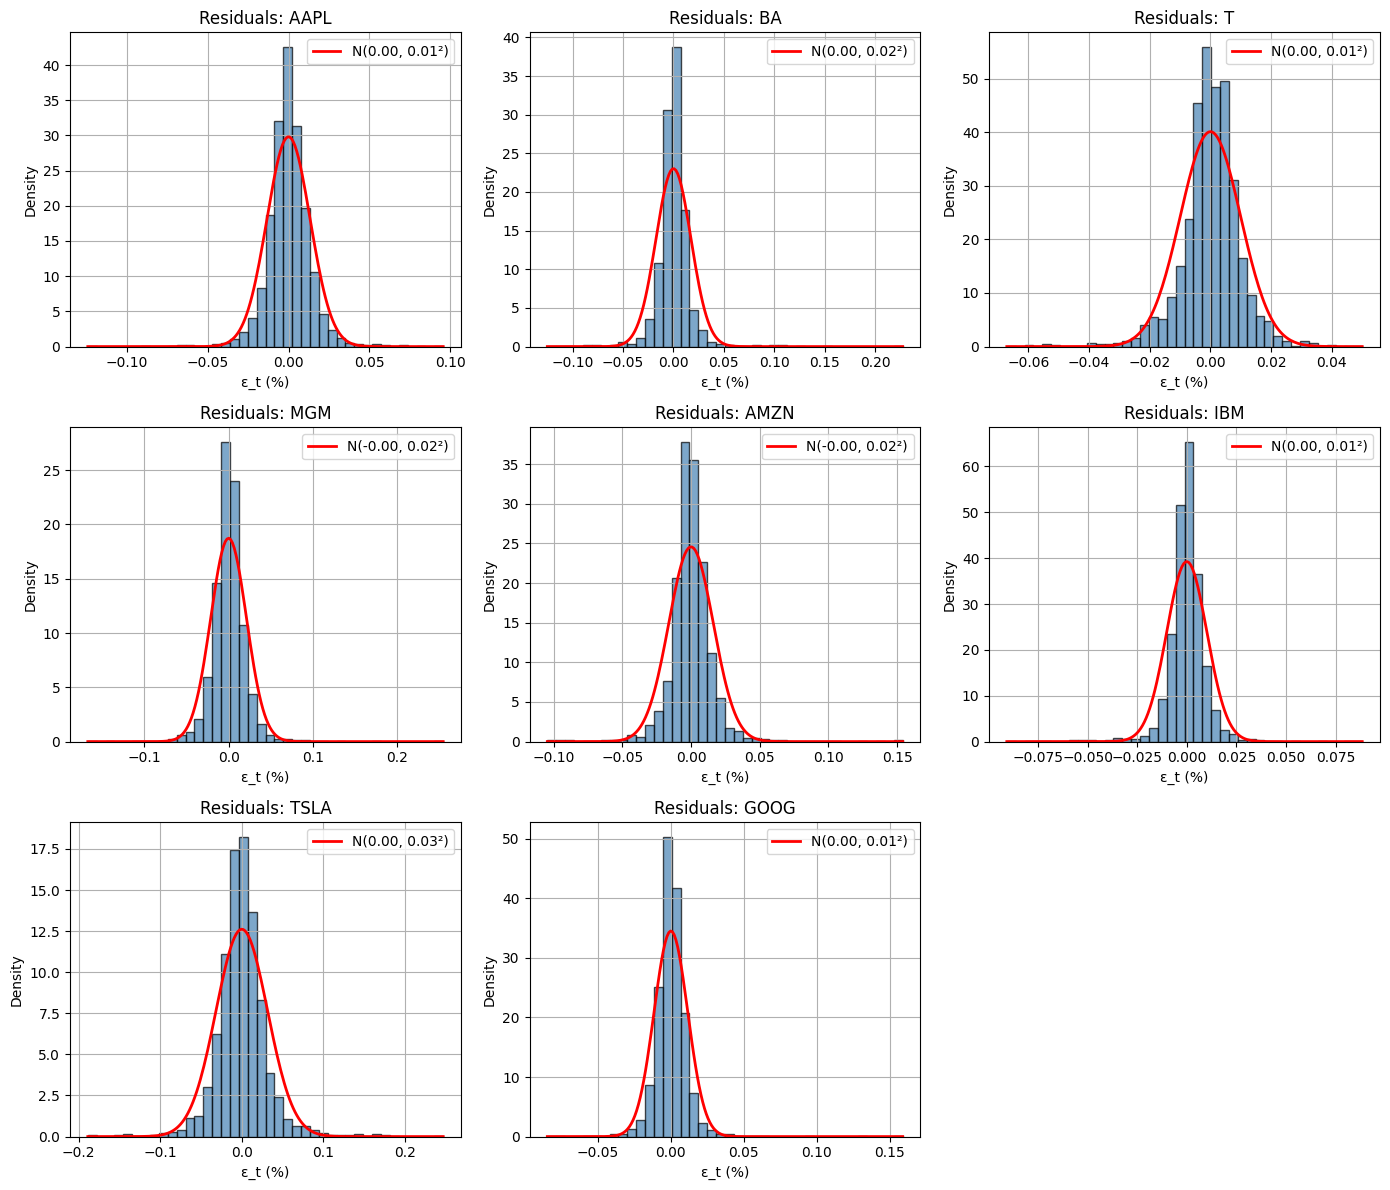

In [112]:
cols = 3
rows_ = int(np.ceil(len(stocks) / cols))
fig, axes = plt.subplots(rows_, cols, figsize=(14, 4 * rows_))
axes = np.array(axes).reshape(-1)

num_bins = 40

for i, s in enumerate(stocks):
    data = residuals[s]

    # Histogram
    axes[i].hist(data, bins=num_bins, alpha=0.7, color="steelblue", 
                 edgecolor="black", density=True)

    # normal distribution
    mu, sigma = np.mean(data), np.std(data)

    # x-values for smooth curve
    x = np.linspace(data.min(), data.max(), 200)
    pdf = norm.pdf(x, mu, sigma)

    axes[i].plot(x, pdf, "r-", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")

    axes[i].set_title(f"Residuals: {s}")
    axes[i].set_xlabel("ε_t (%)")
    axes[i].set_ylabel("Density")
    axes[i].grid(True)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

- Most residuals are roughly bell-shaped and centered around zero (as expected).  
- MGM and TSLA have **fatter tails**, reflecting extreme firm-specific events not explained by CAPM.  
- IBM, GOOG, AAPL show tighter residual distributions → market explains them better.  


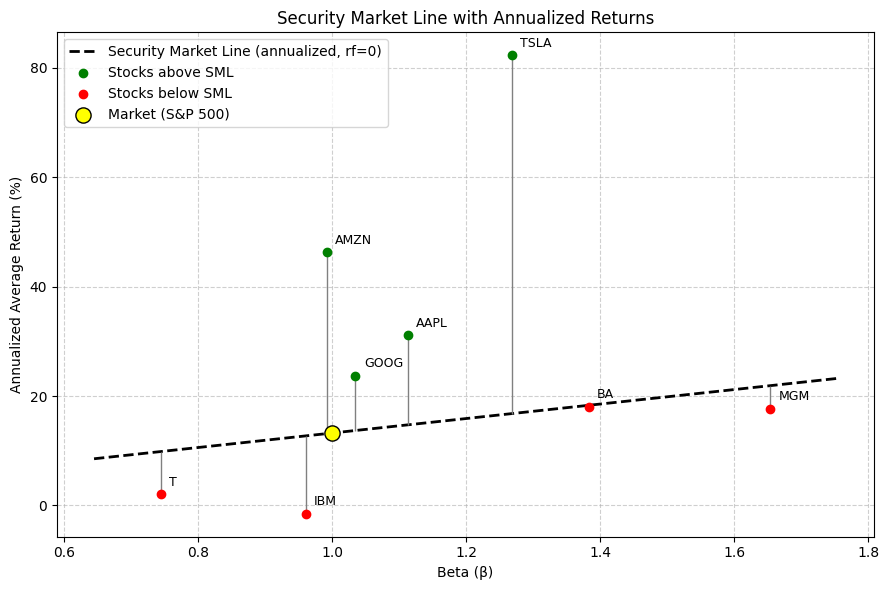

In [113]:
trading_days = 252

# Daily means in DECIMALS
returns_dec = df.pct_change().iloc[1:]
market_dec  = returns_dec["sp500"]
mean_rm_dec = market_dec.mean()
mean_ret_dec = returns_dec[stocks].mean()

# Annualize
annualized_rm = (1 + mean_rm_dec)**trading_days - 1           # market
mean_ret_ann  = (1 + mean_ret_dec)**trading_days - 1          # stocks

# Build SML data (rf = 0)
df_sml = pd.DataFrame({
    "beta": summary["beta"],
    "mean_ret_ann": mean_ret_ann,                              # decimals
})
df_sml["capm_ret_ann"]  = summary["beta"] * annualized_rm      # <-- FIXED
df_sml["alpha_gap_ann"] = df_sml["mean_ret_ann"] - df_sml["capm_ret_ann"]

# SML line
beta_grid = np.linspace(df_sml["beta"].min() - 0.1,
                        df_sml["beta"].max() + 0.1, 200)
sml_ann = beta_grid * annualized_rm

# Plot
plt.figure(figsize=(9,6))
plt.plot(beta_grid, sml_ann*100, "k--", linewidth=2,
         label="Security Market Line (annualized, rf=0)")

# Above/below SML
above = df_sml["alpha_gap_ann"] > 0
below = ~above
plt.scatter(df_sml.loc[above,"beta"], df_sml.loc[above,"mean_ret_ann"]*100,
            color="green", zorder=3, label="Stocks above SML")
plt.scatter(df_sml.loc[below,"beta"], df_sml.loc[below,"mean_ret_ann"]*100,
            color="red",   zorder=3, label="Stocks below SML")

# Market point (β=1)
plt.scatter(1, annualized_rm*100, color="yellow", edgecolor="black",
            s=120, label="Market (S&P 500)", zorder=4)

# Vertical alpha gaps
for stk, row in df_sml.iterrows():
    x = row["beta"]
    y_hat = row["capm_ret_ann"]*100
    y_act = row["mean_ret_ann"]*100
    plt.vlines(x, y_hat, y_act, colors="gray", linewidth=1)
    plt.annotate(stk, (x, y_act), textcoords="offset points", xytext=(6,6), fontsize=9)

plt.title("Security Market Line with Annualized Returns")
plt.xlabel("Beta (β)")
plt.ylabel("Annualized Average Return (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [114]:
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


#### Your boss wants to take a lot of risk to deliver high return. He asks you to (i) select the 4 riskier assets (over the full period), (ii) form an equally weighted portfolio, and (iii) to estimate the portfolio return based on parameters (β and rm) estimated above.

Running on both a Alpha = 0 (under CAPM) and Alpha = mean (realistic)

In [115]:
# Select 4 highest-beta stocks
top4 = summary.head(4).index.tolist()
print("Top 4 by beta:", top4)

# compute equal-weight portfolio beta
beta_p = summary.loc[top4, "beta"].mean()

# Market average daily return (in %)
rm_bar = market.mean()

# ---------- VERSION A: Pure CAPM (alpha = 0) ----------
alpha_CAPM = 0
R_p_CAPM = beta_p * rm_bar

# ---------- VERSION B: Empirical Regression (include alpha) ----------
alpha_empirical = summary.loc[top4, "alpha"].mean()
R_p_REG = alpha_empirical + beta_p * rm_bar

#  results
print("\nEqual-weight risky portfolio (daily % returns):")
print(f"  beta_p = {beta_p:.3f}")
print(f"  market mean return = {rm_bar:.4f}%")

print("\n--- CAPM prediction (alpha=0) ---")
print(f"  alpha_p = {alpha_CAPM:.4f}")
print(f"  Predicted portfolio return = {R_p_CAPM:.4f}%")

print("\n--- Regression-based prediction (with alpha) ---")
print(f"  alpha_p = {alpha_empirical:.4f}")
print(f"  Predicted portfolio return = {R_p_REG:.4f}%")


Top 4 by beta: ['MGM', 'BA', 'TSLA', 'AAPL']

Equal-weight risky portfolio (daily % returns):
  beta_p = 1.354
  market mean return = 0.0005%

--- CAPM prediction (alpha=0) ---
  alpha_p = 0.0000
  Predicted portfolio return = 0.0007%

--- Regression-based prediction (with alpha) ---
  alpha_p = 0.0005
  Predicted portfolio return = 0.0012%


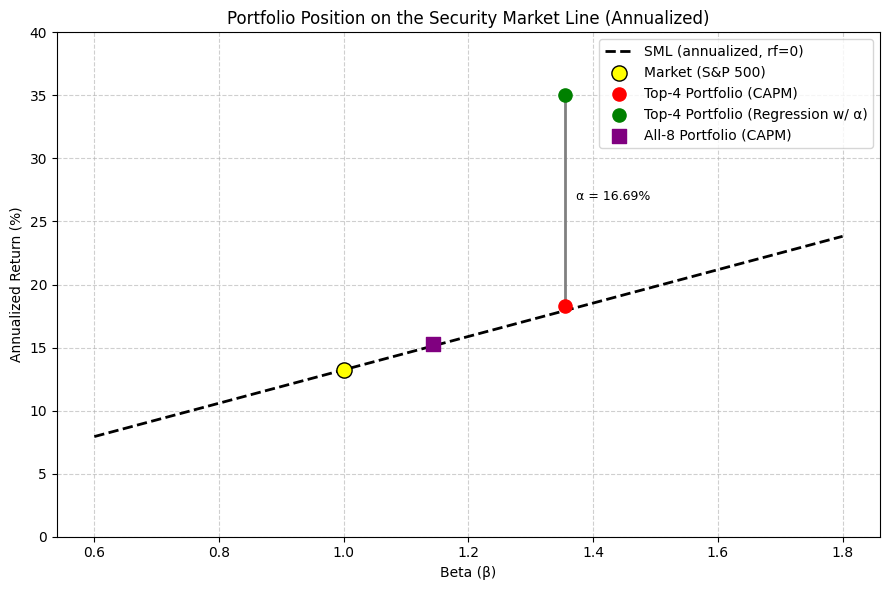

In [116]:
trading_days = 252

# ---- Inputs (DECIMALS) ----
stocks = [c for c in daily_returns.columns if c != "sp500"]
market = daily_returns["sp500"]
rm_bar = market.mean()                              # daily market mean (decimal)
annualized_rm = (1 + rm_bar)**trading_days - 1      # market annualized (decimal)

# Ensure we have alpha in DECIMALS
if "alpha" in summary.columns:
    alpha_col = "alpha"          # daily decimals
elif "alpha(%)" in summary.columns:
    summary["alpha"] = summary["alpha(%)"] / 100.0  # convert % → decimals
    alpha_col = "alpha"
else:
    # if no alpha present, set zeros
    summary["alpha"] = 0.0
    alpha_col = "alpha"

# ---- Portfolio defs ----
# Top-4 by beta (already sorted high→low in your code when created)
top4 = summary.head(4).index.tolist()
beta_p4 = summary.loc[top4, "beta"].mean()
alpha_p4_daily = summary.loc[top4, alpha_col].mean()

# All-8 equal weight (CAPM only requested)
beta_p8 = summary.loc[stocks, "beta"].mean()

# ---- Portfolio returns (daily → annualized) ----
# Top-4: CAPM (alpha=0) vs Regression (with alpha)
R_p4_CAPM_daily = beta_p4 * rm_bar
R_p4_CAPM_ann   = (1 + R_p4_CAPM_daily)**trading_days - 1

R_p4_REG_daily  = alpha_p4_daily + beta_p4 * rm_bar
R_p4_REG_ann    = (1 + R_p4_REG_daily)**trading_days - 1

# Annualized alpha contribution between the green and red dots (approx via compounding difference)
alpha_gap_p4_ann = R_p4_REG_ann - R_p4_CAPM_ann

# All-8: CAPM prediction (alpha=0)
R_p8_CAPM_daily = beta_p8 * rm_bar
R_p8_CAPM_ann   = (1 + R_p8_CAPM_daily)**trading_days - 1

# ---- SML line (annualized) ----
beta_min = min(0.6, summary["beta"].min() - 0.1)
beta_max = max(1.8, summary["beta"].max() + 0.1)
beta_grid = np.linspace(beta_min, beta_max, 200)
sml_ann = beta_grid * annualized_rm  # rf=0

# ---- Plot ----
plt.figure(figsize=(9,6))
plt.plot(beta_grid, sml_ann*100, "k--", linewidth=2,
         label="SML (annualized, rf=0)")

# Market (β=1) — yellow dot
plt.scatter(1, annualized_rm*100, color="yellow", edgecolor="black",
            s=120, zorder=4, label="Market (S&P 500)")

# Top-4 portfolio
plt.scatter(beta_p4, R_p4_CAPM_ann*100, color="red", s=90, zorder=3,
            label="Top-4 Portfolio (CAPM)")
plt.scatter(beta_p4, R_p4_REG_ann*100, color="green", s=90, zorder=3,
            label="Top-4 Portfolio (Regression w/ α)")
# vertical alpha line + label
y0, y1 = R_p4_CAPM_ann*100, R_p4_REG_ann*100
plt.vlines(beta_p4, y0, y1, colors="gray", linewidth=2)
plt.annotate(f"α = {alpha_gap_p4_ann*100:.2f}%",
             (beta_p4, (y0+y1)/2),
             textcoords="offset points", xytext=(8,0), fontsize=9)

# All-8 portfolio CAPM (purple square)
plt.scatter(beta_p8, R_p8_CAPM_ann*100, marker="s", color="purple", s=90, zorder=3,
            label="All-8 Portfolio (CAPM)")

# Aesthetics
plt.title("Portfolio Position on the Security Market Line (Annualized)")
plt.xlabel("Beta (β)")
plt.ylabel("Annualized Return (%)")
plt.ylim(0, 40)                 # y goes up to 40%
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


- The 4 riskiest stocks (by β) are **MGM, BA, TSLA, and AAPL**.  
- The equal-weight portfolio has a **β = 1.354**, meaning it is ~35% more volatile than the market.  
- The average market daily return is **0.0493%**.

**Predictions:**
- **CAPM (α=0):** Expected portfolio return = **0.0668% per day**.  
- **Regression (with α):** Including the average α (0.0524) raises the predicted return to **0.1192% per day**.

**Takeaway:**  
Under CAPM, the portfolio earns higher expected returns because of its high β.  
Empirical regression suggests even greater performance, driven by positive alphas from some stocks.


### Task #3 : Testing the CAPM theory

 #### 1. For each year: compute $\beta_i^{y-1}$ over 252 business days at the end of each year $y-1$ (OLS regression).

In [117]:
def ols_alpha_beta(y, x):
    """
    OLS: y = alpha + beta * x + eps
    y, x = daily % returns aligned on same dates.
    Returns (alpha, beta, R2).
    """
    data = pd.concat([y, x], axis=1).dropna()
    X = sm.add_constant(data.iloc[:, 1].to_numpy(float))
    y_vals = data.iloc[:, 0].to_numpy(float)
    model = sm.OLS(y_vals, X).fit()
    return model.params[0], model.params[1], model.rsquared

In [118]:
def compute_prior_year_betas(daily_returns, window=252):
    """
    For each year y, compute beta_i^{y-1} using the last `window`
    trading days of year (y-1).
    """
    years = sorted(daily_returns.index.year.unique())
    stocks = [c for c in daily_returns.columns if c != "sp500"]

    rows = []
    for y in years[1:]:  # need prior year
        # last date of year y-1
        prev_end = daily_returns.loc[str(y-1)].index.max()
        # last 252 rows before prev_end
        win_idx = daily_returns.loc[:prev_end].tail(window).index
        x_win = daily_returns.loc[win_idx, "sp500"]

        for s in stocks:
            y_win = daily_returns.loc[win_idx, s]
            alpha, beta, r2 = ols_alpha_beta(y_win, x_win)
            rows.append({"year": y, "stock": s,
                         "alpha_prior": alpha,
                         "beta_prior": beta,
                         "R2": r2})
    return pd.DataFrame(rows).set_index(["year", "stock"]).sort_index()

# Compute betas
beta_prior_df = compute_prior_year_betas(daily_returns)
print(beta_prior_df.head())

            alpha_prior  beta_prior        R2
year stock                                   
2013 AAPL      0.000589    1.283028  0.303144
     AMZN      0.001180    1.123074  0.204914
     BA       -0.000378    1.024616  0.484401
     GOOG      0.000213    0.860334  0.240239
     IBM      -0.000071    0.856619  0.454210


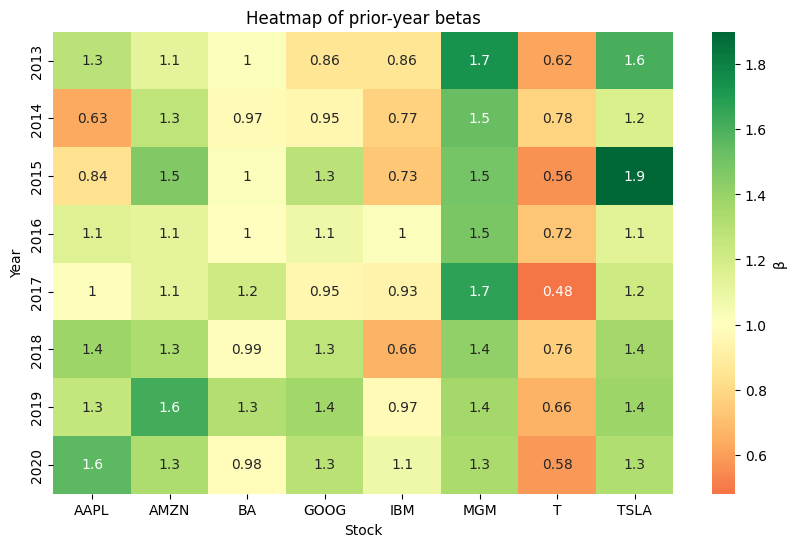

In [119]:
beta_wide = beta_prior_df.reset_index().pivot(index="year", columns="stock", values="beta_prior")

plt.figure(figsize=(10,6))
sns.heatmap(beta_wide.round(2), annot=True, cmap="RdYlGn", center=1.0, cbar_kws={"label": "β"})
plt.title("Heatmap of prior-year betas")
plt.ylabel("Year"); plt.xlabel("Stock")
plt.show()


- MGM and TSLA frequently show high betas (>1.5) → they are consistently more volatile and sensitive to the market.

- T (AT&T) often has the lowest betas (<0.7) → it is the most defensive stock in this set.

- AAPL, AMZN, GOOG, and BA hover closer to 1–1.3, reflecting risk similar to or slightly above the market.

- Shifts over time are visible (e.g., AMZN’s beta rising in later years, TSLA staying high, MGM decreasing slightly.)

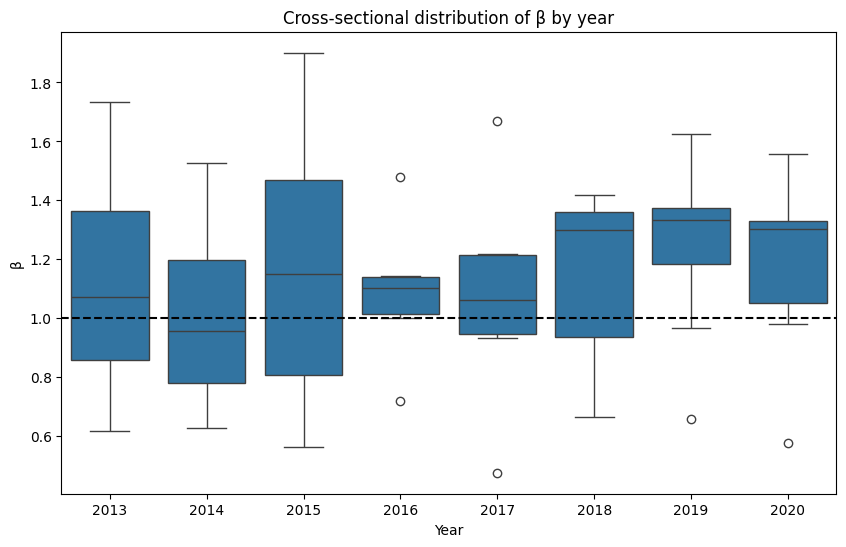

In [120]:
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="beta_prior", data=beta_prior_df.reset_index())
plt.axhline(1.0, linestyle="--", color="black")
plt.title("Cross-sectional distribution of β by year")
plt.ylabel("β"); plt.xlabel("Year")
plt.show()


- Most betas cluster around 1, but the spread varies across years.

- In some years (2013, 2015), the dispersion is wide: some stocks are very defensive (β < 0.7) while others are highly aggressive (β > 1.7).

- In other years (2016–2017), betas are more compressed, suggesting stocks were moving more in line with the market.

- The median beta is usually slightly above 1, meaning the “average stock” is a bit riskier than the market.

#### 2. At the end of year $y$, compare the average return of the stock $\bar{r}_i^y$ (annualized) to the one predicted by the CAPM model $\hat{r}_i^y$  (using $\beta_i^{y-1}$ measured at $y-1$, but the average market return $\bar{r}_M^y$ measured at $y$).


In [121]:
def annualize_from_daily_decimal(daily_dec: pd.Series, trading_days: int = 252) -> float:
    """
    Geometric annualization from daily *decimal* returns.
    Returns an annualized *decimal* (e.g., 0.08 = 8%).
    """
    r = pd.to_numeric(daily_dec, errors="coerce").dropna().to_numpy()
    if r.size == 0:
        return np.nan
    gross = np.prod(1.0 + r)
    return gross**(trading_days / r.size) - 1.0

# Build realized annualized returns for each stock i and the market in year y
def realized_annualized_returns_dec(daily_returns_dec: pd.DataFrame) -> pd.DataFrame:
    """
    Build realized annualized returns for each stock i and the market in year y,
    using daily *decimal* returns; outputs *decimals*.
    """
    years  = sorted(daily_returns_dec.index.year.unique())
    stocks = [c for c in daily_returns_dec.columns if c != "sp500"]

    rows = []
    for y in years:
        yr = daily_returns_dec.loc[str(y)]
        if yr.empty:
            continue
        rM_y = annualize_from_daily_decimal(yr["sp500"])  # market, decimal
        for s in stocks:
            ri_y = annualize_from_daily_decimal(yr[s])     # stock, decimal
            rows.append({
                "year": y, "stock": s,
                "r_realized_ann": ri_y,   # decimal
                "rM_ann": rM_y            # decimal
            })
    return pd.DataFrame(rows).set_index(["year", "stock"]).sort_index()

# Build realized returns
realized_df = realized_annualized_returns_dec(daily_returns)     # decimals
print(realized_df.head())

            r_realized_ann    rM_ann
year stock                          
2012 AAPL         0.275131  0.105261
     AMZN         0.447028  0.105261
     BA          -0.002069  0.105261
     GOOG         0.128885  0.105261
     IBM          0.063521  0.105261


In [122]:
# Join with beta data
panel = beta_prior_df.join(realized_df, how="inner")

# CAPM prediction (r_f = 0): r_hat_i^y = beta_i^{y-1} * rM^y
panel["r_capm_pred_ann"] = panel["beta_prior"] * panel["rM_ann"]        # decimal
panel["prediction_error"] = panel["r_realized_ann"] - panel["r_capm_pred_ann"]  # decimal

# Convert to percentages for display
panel["r_realized_ann(%)"] = panel["r_realized_ann"] * 100
panel["r_capm_pred_ann(%)"] = panel["r_capm_pred_ann"] * 100
panel["prediction_error(%)"] = panel["prediction_error"] * 100
panel["rM_ann(%)"] = panel["rM_ann"] * 100

print(panel.round(3).head(12))

            alpha_prior  beta_prior     R2  r_realized_ann  rM_ann  \
year stock                                                           
2013 AAPL         0.001       1.283  0.303           0.054   0.296   
     AMZN         0.001       1.123  0.205           0.590   0.296   
     BA          -0.000       1.025  0.484           0.811   0.296   
     GOOG         0.000       0.860  0.240           0.584   0.296   
     IBM         -0.000       0.857  0.454          -0.021   0.296   
     MGM         -0.001       1.733  0.382           1.021   0.296   
     T            0.000       0.616  0.308           0.043   0.296   
     TSLA         0.001       1.611  0.147           3.441   0.296   
2014 AAPL        -0.000       0.627  0.059           0.377   0.114   
     AMZN         0.001       1.265  0.269          -0.222   0.114   
     BA           0.001       0.967  0.254          -0.048   0.114   
     GOOG         0.001       0.945  0.228          -0.060   0.114   

            r_capm_

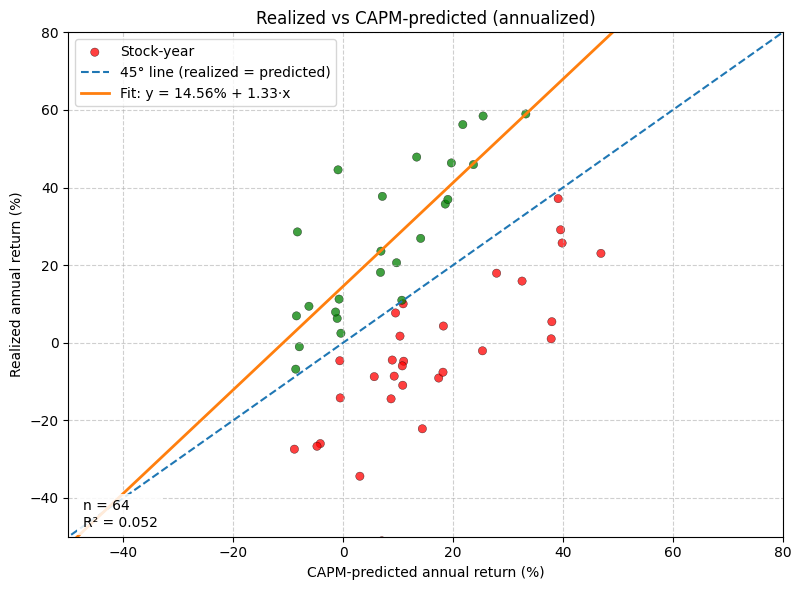

In [123]:
def plot_realized_vs_capm(panel: pd.DataFrame,
                          title: str = "Realized vs CAPM-predicted (annualized)") -> None:
    # Pull columns in DECIMALS for calculation
    x_dec = pd.to_numeric(panel["r_capm_pred_ann"],  errors="coerce").to_numpy()
    y_dec = pd.to_numeric(panel["r_realized_ann"],   errors="coerce").to_numpy()
    err_dec = pd.to_numeric(panel["prediction_error"], errors="coerce").to_numpy()

    m = np.isfinite(x_dec) & np.isfinite(y_dec)
    xv_dec, yv_dec, ev_dec = x_dec[m].astype(float), y_dec[m].astype(float), err_dec[m].astype(float)
    if xv_dec.size < 2:
        raise ValueError("Not enough finite observations to plot/regress.")

    # Colors: green if realized > predicted, red otherwise
    colors = np.where(ev_dec >= 0, "green", "red")

    # Convert to % for plotting
    xv_pct = xv_dec * 100.0
    yv_pct = yv_dec * 100.0

    plt.figure(figsize=(8,6))
    plt.scatter(xv_pct, yv_pct, c=colors, alpha=0.75, edgecolor="k", linewidth=0.3, label="Stock-year")

    # 45° line (in % space)
    lo = float(min(xv_pct.min(), yv_pct.min()))
    hi = float(max(xv_pct.max(), yv_pct.max()))
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    x_line_pct = np.linspace(lo - pad, hi + pad, 200)
    plt.plot(x_line_pct, x_line_pct, linestyle="--", linewidth=1.5, label="45° line (realized = predicted)")

    # OLS fit on DECIMALS (cleaner), then convert fitted line to %
    Xmat = sm.add_constant(xv_dec)
    fit = sm.OLS(yv_dec, Xmat).fit()
    yhat_line_pct = (fit.params[0] + fit.params[1] * (x_line_pct / 100.0)) * 100.0
    plt.plot(x_line_pct, yhat_line_pct, linewidth=2,
             label=f"Fit: y = {fit.params[0]*100:.2f}% + {fit.params[1]:.2f}·x")

    plt.xlabel("CAPM-predicted annual return (%)")
    plt.ylabel("Realized annual return (%)")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="best")

    # Stats box
    plt.text(0.02, 0.02,
             f"n = {xv_dec.size}\nR² = {fit.rsquared:.3f}",
             transform=plt.gca().transAxes,
             fontsize=10,
             bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    plt.tight_layout()
    plt.xlim(-50, 80)
    plt.ylim(-50, 80)
    plt.show()

# Plot realized vs predicted returns
plot_realized_vs_capm(panel)

**Interpretation:**  
The 45° dashed line represents the case where realized returns equal CAPM-predicted returns.   The regression line (orange) lies close to this benchmark, with a positive slope, which suggests that higher CAPM-predicted returns are generally associated with higher realized returns.  

However, the dispersion of points around the line is wide, and the fit is not very tight.   This indicates that while CAPM-predicted returns provide *some* directional guidance, they explain only a small fraction of the variation in realized returns.   One possible explanation is that returns are influenced by other risk factors (size, value, momentum, etc.) or by firm-specific events that CAPM does not capture.   This is consistent with empirical evidence that the CAPM often struggles to account for cross-sectional differences in returns.


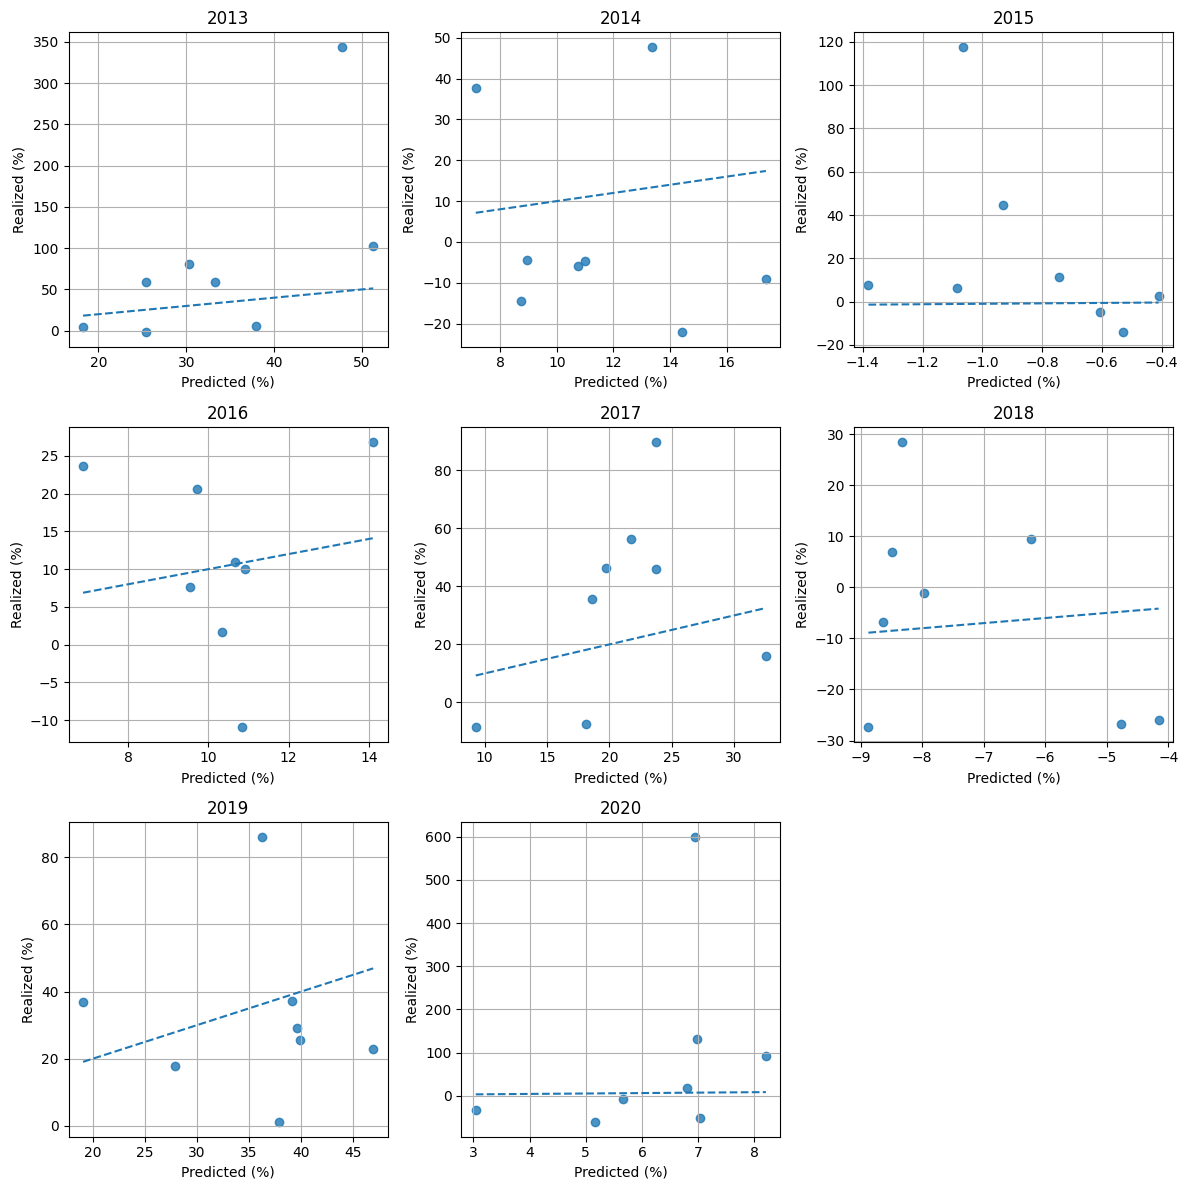

In [124]:
years = sorted(panel.index.get_level_values(0).unique())
n = len(years)
cols = 3
rows = (n + cols - 1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(12,4*rows)); axes = axes.ravel()

for i, y_ in enumerate(years):
    sub = panel.loc[y_]
    xv = sub["r_capm_pred_ann(%)"].to_numpy(); yv = sub["r_realized_ann(%)"].to_numpy()
    m = np.isfinite(xv) & np.isfinite(yv)
    ax = axes[i]
    ax.scatter(xv[m], yv[m], alpha=0.8)
    # 45°
    xl = np.linspace(np.min(xv[m]), np.max(xv[m]), 100)
    ax.plot(xl, xl, linestyle="--")
    ax.set_title(str(y_)); ax.set_xlabel("Predicted (%)"); ax.set_ylabel("Realized (%)"); ax.grid(True)

for j in range(i+1, len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.show()


**Interpretation:**  
The plots illustrate how the relationship between realized returns and CAPM-predicted returns changes across years:

- **2013, 2015, 2017:** Slopes are positive, meaning stocks with higher predicted returns tended to have higher realized returns. However, the scatter is wide, suggesting only weak explanatory power.  
- **2014, 2018, 2019:** The slopes are flatter, and in some cases slightly negative. This implies that CAPM predictions were less aligned with realized outcomes in those years.  
- **2016:** The relationship looks somewhat tighter, with realized returns moving more consistently with predictions.  
- **2020:** Realized returns are extremely dispersed (one outlier are far above the rest), which overwhelms the fitted line. This reflects that extraordinary events (e.g., COVID-19) likely drove firm-specific shocks that CAPM cannot capture.

**Overall:**  
Across years, the explanatory power of CAPM appears inconsistent — in some periods it aligns reasonably with realized returns, but in others the predictions do not track actual outcomes well.  
One possible explanation is that market conditions, macro shocks, and omitted risk factors (like size or value effects) dominate in certain years, making β an unreliable predictor on its own.


#### 3. Generate the scatter plot of the realized returns against the betas, or find innovative ways to visualize your results.


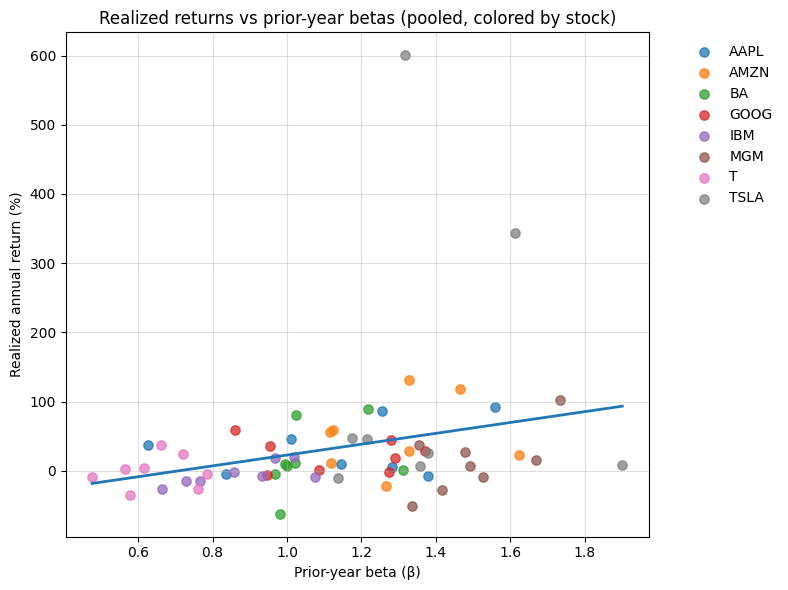

Slope (pooled): 78.356   R^2 (pooled): 0.075


In [125]:
df_scatter = panel.reset_index()[["stock","beta_prior","r_realized_ann(%)"]]
stocks = sorted(df_scatter["stock"].unique())

# consistent colors per stock
cmap = plt.get_cmap("tab10")
color_map = {s: cmap(i % 10) for i, s in enumerate(stocks)}

plt.figure(figsize=(8,6))
for s in stocks:
    sub = df_scatter[df_scatter["stock"] == s]
    plt.scatter(sub["beta_prior"], sub["r_realized_ann(%)"],
                alpha=0.75, s=45, label=s, color=color_map[s])

# overall regression line (realized on beta)
x = df_scatter["beta_prior"].to_numpy()
y = df_scatter["r_realized_ann(%)"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)
X = sm.add_constant(x[m])
fit = sm.OLS(y[m], X).fit()
xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
plt.plot(xx, fit.params[0] + fit.params[1]*xx, linewidth=2)

plt.xlabel("Prior-year beta (β)")
plt.ylabel("Realized annual return (%)")
plt.title("Realized returns vs prior-year betas (pooled, colored by stock)")
plt.grid(True, alpha=0.4)

# Legend outside
plt.legend(
    ncol=1,
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


print(f"Slope (pooled): {fit.params[1]:.3f}   R^2 (pooled): {fit.rsquared:.3f}")


**Interpretation:**  
The regression line shows a positive slope, suggesting that stocks with higher prior-year betas tended, on average, to earn somewhat higher realized returns.  
However, the relationship is weak — points are widely scattered, and the explanatory power is low.  

Some stocks, such as Tesla (grey), show extreme realized returns (both very high and very negative in some years), which create large outliers. 

Defensive stocks like AT&T (pink) cluster around lower betas (<1) and generally lower realized returns, while cyclical stocks such as MGM and BA spread out more widely.  

Overall, the plot indicates that β may carry some information about future returns, but the signal is noisy and inconsistent.  

One explanation could be that realized returns are driven not just by systematic risk (β) but also by firm-specific shocks and additional risk factors (e.g., value, growth, momentum).  

This aligns with the broader evidence that CAPM’s single-factor approach has limited ability to explain cross-sectional returns.


#### Based on the preivous results, rerunning the graph but excluding tesla since it has been shown to violate capm a lot

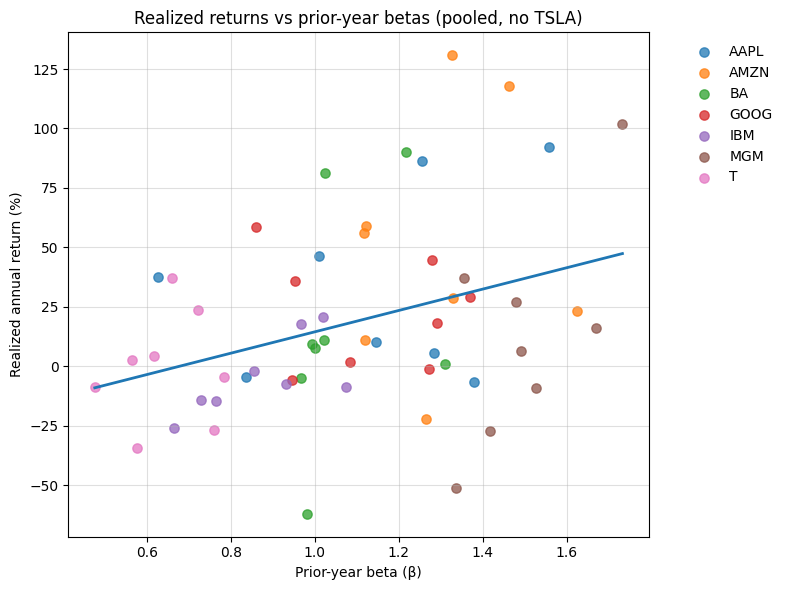

Slope (pooled, no TSLA): 44.947   R^2: 0.121


In [126]:
# ========= EXCLUDE TESLA =========
df_no_tsla = df_scatter[df_scatter["stock"] != "TSLA"].copy()

# Colors (rebuild without TSLA)
stocks = sorted(df_no_tsla["stock"].unique())
cmap = plt.get_cmap("tab10")
color_map = {s: cmap(i % 10) for i, s in enumerate(stocks)}

plt.figure(figsize=(8,6))

# Points per stock (no TSLA)
for s in stocks:
    sub = df_no_tsla[df_no_tsla["stock"] == s]
    plt.scatter(
        sub["beta_prior"], sub["r_realized_ann(%)"],
        alpha=0.75, s=45, label=s, color=color_map[s]
    )

# ========= REGRESSION (no TSLA) =========
x = df_no_tsla["beta_prior"].to_numpy()
y = df_no_tsla["r_realized_ann(%)"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)
X = sm.add_constant(x[m])
fit = sm.OLS(y[m], X).fit()

# Fitted line
xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
yy = fit.params[0] + fit.params[1]*xx
plt.plot(xx, yy, linewidth=2)

plt.xlabel("Prior-year beta (β)")
plt.ylabel("Realized annual return (%)")
plt.title("Realized returns vs prior-year betas (pooled, no TSLA)")
plt.grid(True, alpha=0.4)

# Legend outside
plt.legend(
    ncol=1,
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

print(f"Slope (pooled, no TSLA): {fit.params[1]:.3f}   R^2: {fit.rsquared:.3f}")


**Interpretation (with vs. without Tesla):**

- **With Tesla (top panel):**  
  The regression slope is steeper (≈78) but the explanatory power is low (R² ≈ 0.075).  
  This reflects that Tesla’s extreme realized returns exert a strong pull on the regression line, but because they are outliers, they do not improve the fit for most other stocks.

- **Without Tesla (bottom panel):**  
  The slope becomes smaller (≈45), but R² rises (≈0.121).  
  This suggests that the overall relationship between β and realized returns becomes *tighter* once Tesla’s outsized influence is removed.  
  The data look more balanced across stocks, and the regression line better reflects the central tendency of the sample.

**Takeaway:**  
Tesla’s extreme realized returns act as influential outliers — they inflate the slope but weaken the fit across the rest of the sample.  
When excluded, the CAPM β–return relationship appears more stable, though still noisy.  


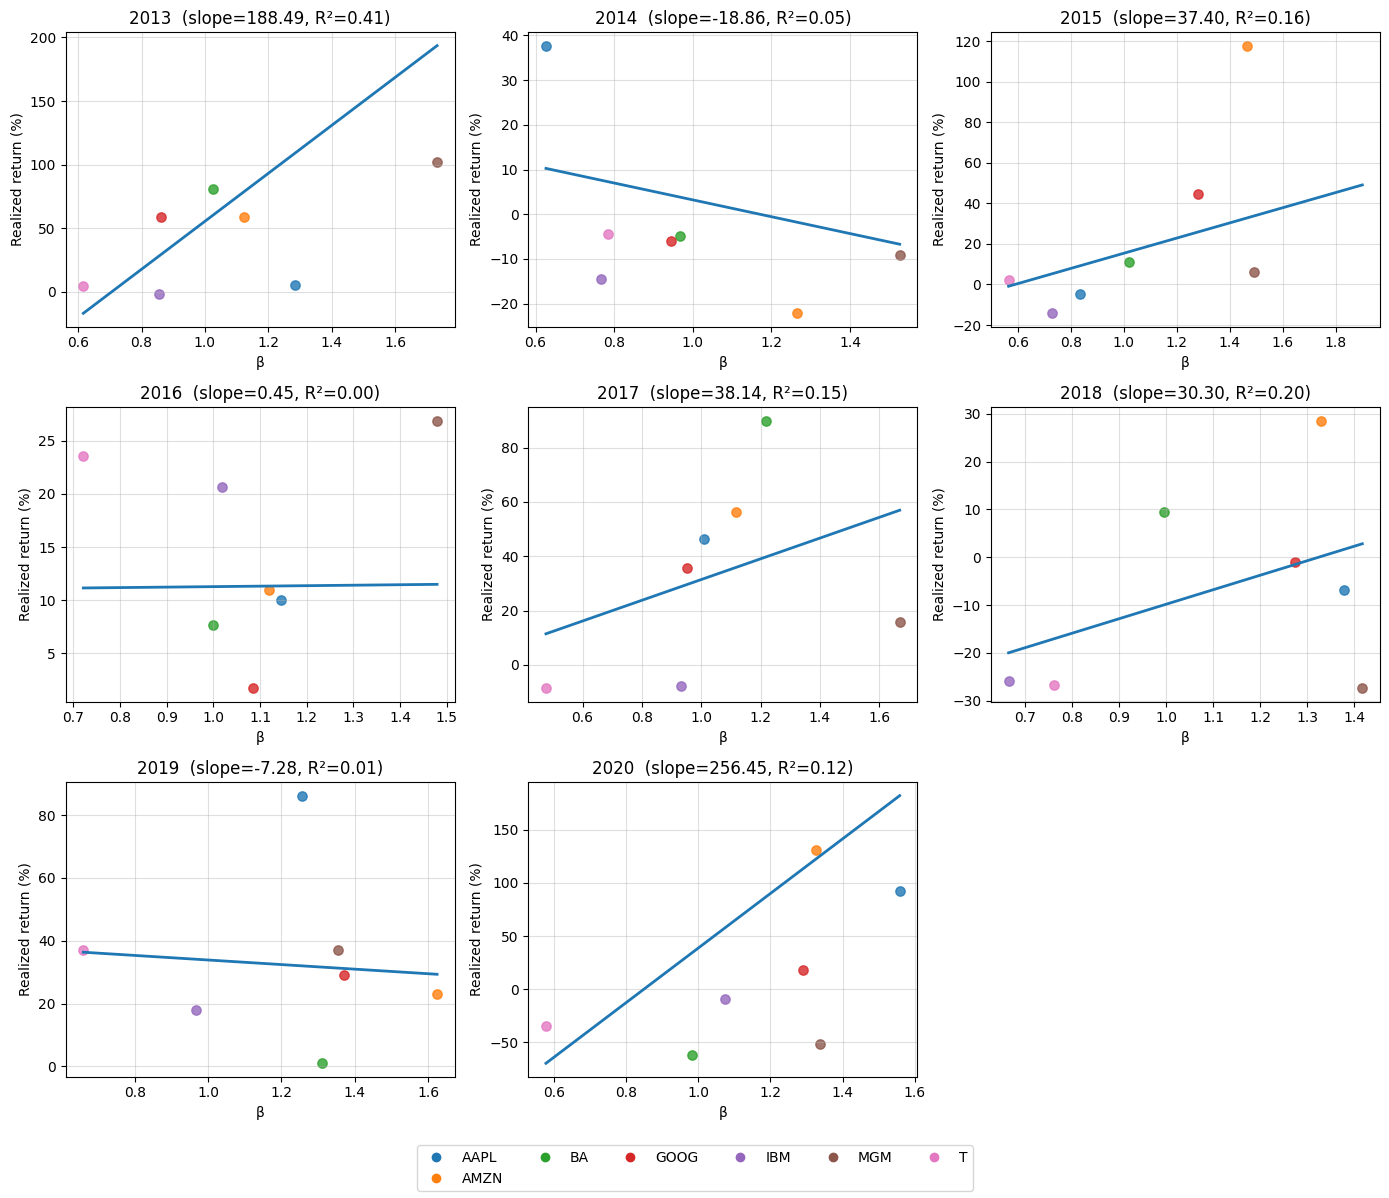

In [127]:
years = sorted(panel.index.get_level_values(0).unique())
df_scatter_y = panel.reset_index()[["year","stock","beta_prior","r_realized_ann(%)"]]

cols = 3
rows = math.ceil(len(years) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows), squeeze=False)

for i, y in enumerate(years):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    sub = df_scatter_y[df_scatter_y["year"] == y]

    # plot points by stock with consistent colors
    for s in stocks:
        ss = sub[sub["stock"] == s]
        if not ss.empty:
            ax.scatter(ss["beta_prior"], ss["r_realized_ann(%)"],
                       alpha=0.8, s=45, color=color_map[s])

    # regression per year
    x = sub["beta_prior"].to_numpy()
    yv = sub["r_realized_ann(%)"].to_numpy()
    m = np.isfinite(x) & np.isfinite(yv)
    if m.sum() >= 3:
        X = sm.add_constant(x[m])
        fit = sm.OLS(yv[m], X).fit()
        xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 100)
        ax.plot(xx, fit.params[0] + fit.params[1]*xx, linewidth=2)
        ax.set_title(f"{int(y)}  (slope={fit.params[1]:.2f}, R²={fit.rsquared:.2f})")
    else:
        ax.set_title(f"{int(y)}")

    ax.grid(True, alpha=0.4)
    ax.set_xlabel("β"); ax.set_ylabel("Realized return (%)")

# hide any empty subplots
for j in range(i+1, rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

# single shared legend below the grid
handles = [plt.Line2D([0],[0], marker='o', linestyle='', color=color_map[s], label=s) for s in stocks]
fig.legend(handles=handles, labels=stocks, loc="lower center", ncol=min(6, len(stocks)))
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()


**Interpretation:**  
The yearly plots highlight how unstable the CAPM β–return relationship can be across different market environments:

- **2013, 2015, 2017, 2018, 2020:** Slopes are positive, suggesting that in these years higher β stocks tended to deliver higher realized returns. However, the strength of the fit varies: 2013 shows a strong slope with moderate R², while 2016 and 2020 show very noisy outcomes despite positive slopes.  
- **2014, 2019:** Slopes are negative, indicating that higher β stocks underperformed relative to lower β ones in those years. This contradicts CAPM’s prediction.  
- **2016:** The slope is nearly flat with R² ≈ 0, showing no apparent relationship between β and returns.  
- **2020:** The slope is very steep due to extreme observations (notably Tesla), but R² is still low, reflecting wide dispersion around the line.

**Overall pattern:**  
- The direction and strength of the β–return link changes year by year, with some years showing weak or even inverted relationships.  
- The generally low R² values imply that β alone explains little of the variation in realized returns within a given year.  
- This variability supports the idea that CAPM, as a single-factor model, has limited explanatory power in real-world data and that additional factors (size, value, momentum, etc.) may be needed for more stable predictions.


#### 4. Alternatively, you may use a $\beta$ computed over longer (or shorter) periods of time.


In [128]:
windows = [63, 126, 252, 504]

def fit_metrics(df, xcol="r_capm_pred_ann(%)", ycol="r_realized_ann(%)"):
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    X = sm.add_constant(x[m])
    fit = sm.OLS(y[m], X).fit()
    resid = y[m] - fit.predict(X)
    out = {
        "slope": float(fit.params[1]),
        "R2": float(fit.rsquared),
        "MAE(%)": float(np.mean(np.abs(resid))),
        "RMSE(%)": float(np.sqrt(np.mean(resid**2))),
        "n": int(m.sum())
    }
    return out, fit, m

# Gather panels + metrics
panels = {}
metrics_rows = []

for w in windows:
    betas_w = compute_prior_year_betas(daily_returns, window=w)
    pan = betas_w.join(realized_df, how="inner")
    pan["r_capm_pred_ann"] = pan["beta_prior"] * pan["rM_ann"]
    pan["prediction_error"] = pan["r_realized_ann"] - pan["r_capm_pred_ann"]
    
    # Convert to percentages
    pan["r_capm_pred_ann(%)"] = pan["r_capm_pred_ann"] * 100
    pan["r_realized_ann(%)"] = pan["r_realized_ann"] * 100
    pan["prediction_error(%)"] = pan["prediction_error"] * 100
    pan["rM_ann(%)"] = pan["rM_ann"] * 100

    (mrow, fit, mask) = fit_metrics(pan)
    mrow["window"] = w
    metrics_rows.append(mrow)
    panels[w] = (pan, fit, mask)

metrics = pd.DataFrame(metrics_rows).set_index("window").sort_index()
print(metrics.round(3))

        slope     R2  MAE(%)  RMSE(%)   n
window                                   
63      0.537  0.009  45.285   89.964  64
126     0.944  0.026  44.100   89.172  64
252     1.335  0.052  42.277   87.999  64
504     1.358  0.052  42.139   87.983  64


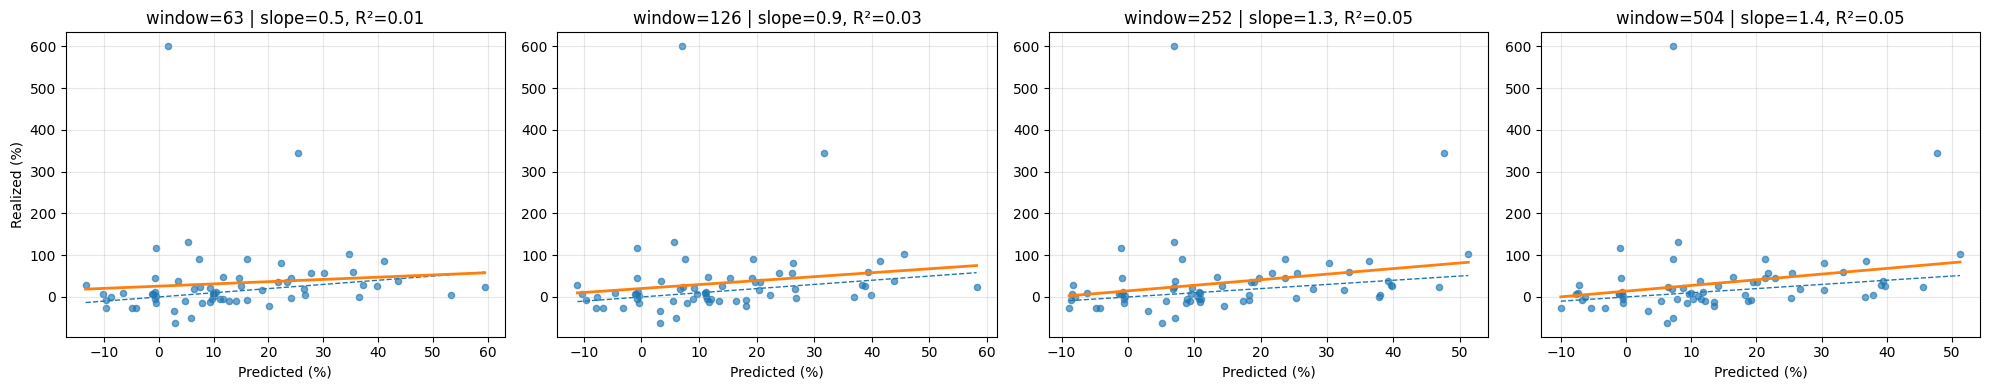

In [129]:
# One scatter per window: realized vs predicted, 45° line + regression
nW = len(windows)
fig, axes = plt.subplots(1, nW, figsize=(5*nW, 4), squeeze=False)

for j, w in enumerate(windows):
    pan, fit, m = panels[w]
    ax = axes[0, j]
    x = pan["r_capm_pred_ann(%)"].to_numpy(); y = pan["r_realized_ann(%)"].to_numpy()
    ax.scatter(x[m], y[m], alpha=0.65, s=20)
    xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
    ax.plot(xx, xx, linestyle="--", linewidth=1)  # 45°
    ax.plot(xx, fit.params[0] + fit.params[1]*xx, linewidth=2)  # regression

    ax.set_title(f"window={w} | slope={fit.params[1]:.1f}, R²={fit.rsquared:.2f}")
    ax.set_xlabel("Predicted (%)")
    if j == 0: ax.set_ylabel("Realized (%)")
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


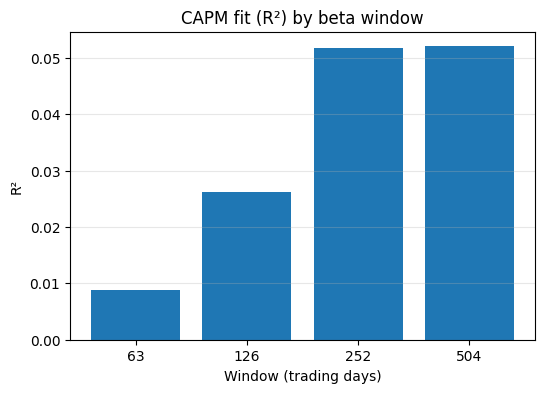

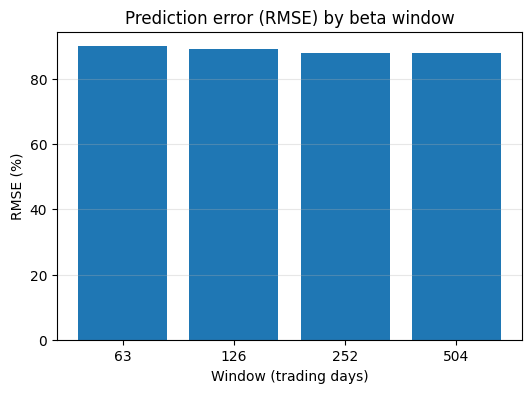

In [130]:
# R² by window
plt.figure(figsize=(6,4))
plt.bar([str(w) for w in metrics.index], metrics["R2"].values)
plt.title("CAPM fit (R²) by beta window")
plt.xlabel("Window (trading days)")
plt.ylabel("R²")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# RMSE by window
plt.figure(figsize=(6,4))
plt.bar([str(w) for w in metrics.index], metrics["RMSE(%)"].values)
plt.title("Prediction error (RMSE) by beta window")
plt.xlabel("Window (trading days)")
plt.ylabel("RMSE (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


**Task 3.4 – Interpretation (different β windows):**  
The estimation window influences the slope and fit of the CAPM regressions.  
- Very short windows (63, 126 trading days) produce noisier betas, yielding almost no explanatory power.  
- Longer windows (252, 504 days) give slightly stronger slopes and marginally higher R², but overall fit remains weak.  
- RMSE is large and stable across all windows, showing that prediction errors are substantial no matter how β is estimated.  

One explanation could be that CAPM’s single β factor captures only a small part of return variation, while firm-specific shocks and additional risk factors dominate. The choice of window alters the smoothness of β estimates but does not fundamentally change CAPM’s limited predictive ability.


#### 5. Comment on your results in the light of yesterday’s lecture: try to give as much economic interpretation as you can!


The pooled and year-by-year results suggest that prior-year β has a **positive but weak** association with realized returns. One possible explanation is that β captures exposure to broad market risk, but realized outcomes also depend on **additional risk factors** (size, value, momentum) and **firm-specific factors** that CAPM does not model. Moreover, **historical averages** are poor predictors when based on **relatively short time series**, since idiosyncratic shocks can dominate the signal.

Years such as **2014 and 2019** show flat or negative β–return slopes, while **2013, 2015, 2017, 2018** show positive slopes, and **2020** is dominated by large outliers. One interpretation is that **macro shocks** (e.g., COVID-19) and **sector-specific cycles intermittently dominate**, making β a less reliable cross-sectional predictor in those periods.

Finally, **excluding TSLA** reduces the influence of extreme observations and often improves fit slightly, which could indicate that part of the weak CAPM performance owes to **idiosyncratic extremes** rather than the model’s structure alone. In addition, factors such as the **cyclicality of demand, exposure to credit market conditions, and technological shocks** should also be taken into account when interpreting realized returns. 

Overall, these patterns align with the view that **single-factor CAPM is a useful benchmark but incomplete**, motivating multi-factor models in practice.


### Optional Task : Obtain data from the web

Web-scrapping : get the list of S&P 500 tickers from Wikipedia

In [131]:
url = 'http://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/111.0.0.0 Safari/537.36'
}

resp = requests.get(url, headers=headers) 
soup = bs.BeautifulSoup(resp.text, 'lxml')

table = soup.find('table', {'id': 'constituents'})
tickers = []

for row in table.find_all('tr')[1:]:  
    cols = row.find_all('td')
    if cols:  
        ticker = cols[0].text.strip()
        tickers.append(ticker)

print(len(tickers))  
tickers

503


['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'KMX',
 'CCL',
 'CARR',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'CAG',
 'COP',
 'ED',
 'STZ',
 'CEG',


### Use the list of tickers as input in the yfinance package (an API that gives access to Yahoo Finance data)

In [132]:
tickers = [s.replace('.','-') for s in tickers]

start = datetime.datetime(2012, 1, 12)
data = yf.download(tickers, start=start, end=None)

C:\Users\lasko\AppData\Local\Temp\ipykernel_31372\1215478638.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=None)
[*********************100%***********************]  503 of 503 completed


In [133]:
data.head()

Price           Close                                                        \
Ticker              A       AAPL ABBV ABNB        ABT       ACGL        ACN   
Date                                                                          
2012-01-12  25.166056  12.650176  NaN  NaN  20.267292  11.794311  41.967880   
2012-01-13  24.873137  12.602746  NaN  NaN  20.366508  11.781633  41.431023   
2012-01-17  25.465355  12.749544  NaN  NaN  20.469378  11.708730  41.617752   
2012-01-18  26.280443  12.881931  NaN  NaN  20.340778  11.715070  42.753700   
2012-01-19  26.649782  12.841107  NaN  NaN  20.366508  11.692883  42.636990   

Price                                                                         \
Ticker           ADBE        ADI        ADM        ADP       ADSK        AEE   
Date                                                                           
2012-01-12  29.230000  27.359520  19.897564  35.343521  32.299999  20.319111   
2012-01-13  28.969999  26.853540  19.918053  35.337090  31.920000  20.312820   
2012-01-17  29.350000  27.161539  19.651743  35.793674  32.160000  20.344233   
2012-01-18  29.889999  28.708807  19.952192  36.333855  34.340000  20.174593   
2012-01-19  30.240000  29.090115  20.088758  36.591087  35.430000  19.829027   

Price                                                                        \
Ticker            AEP       AES        AFL        AIG        AIZ        AJG   
Date                                                                          
2012-01-12  24.838764  8.207712  15.795604  19.370770  29.037329  24.385296   
2012-01-13  24.850771  8.273115  15.476604  19.005133  29.044956  24.341009   
2012-01-17  24.886812  8.423533  15.684491  18.708063  29.151651  24.245058   
2012-01-18  24.952900  8.364672  16.193443  19.218430  29.730873  24.569811   
2012-01-19  24.688589  8.449692  16.892365  19.462179  29.898539  24.451717   

Price                                                                       \
Ticker           AKAM        ALB       ALGN        ALL ALLE      AMAT AMCR   
Date                                                                         
2012-01-12  33.570000  46.951389  24.709999  21.575048  NaN  9.555003  NaN   
2012-01-13  32.220001  46.387875  24.080000  21.508255  NaN  9.312078  NaN   
2012-01-17  32.130001  46.828880  24.910000  21.560217  NaN  9.538809  NaN   
2012-01-18  32.410000  47.784416  24.790001  21.871922  NaN  9.814124  NaN   
2012-01-19  32.689999  49.074772  25.240000  21.886770  NaN  9.967976  NaN   

Price                                                                      \
Ticker       AMD        AME       AMGN        AMP        AMT    AMZN ANET   
Date                                                                        
2012-01-12  5.82  27.847961  46.809315  38.446537  46.788960  8.7965  NaN   
2012-01-13  5.66  28.030699  46.850899  38.068825  46.691586  8.9210  NaN   
2012-01-17  5.73  27.713959  47.176620  38.209538  46.324451  9.0830  NaN   
2012-01-18  5.97  27.555593  47.973644  38.883530  46.766491  9.4720  NaN   
2012-01-19  6.22  28.103783  47.918201  39.735249  46.601677  9.7225  NaN   

Price                                                                          \
Ticker            AON       AOS        APA        APD       APH       APO APP   
Date                                                                            
2012-01-12  40.605236  8.720194  71.076805  59.533161  5.312975  5.625893 NaN   
2012-01-13  40.265911  8.560026  69.976357  59.387859  5.306364  5.605360 NaN   
2012-01-17  40.439930  8.598549  71.355705  59.737904  5.319587  5.798365 NaN   
2012-01-18  40.848854  8.699918  71.928528  60.477718  5.902574  5.942094 NaN   
2012-01-19  41.327370  8.578276  73.347771  60.662674  6.049146  6.057074 NaN   

Price                                                                        \
Ticker           APTV        ARE        ATO        AVB      AVGO        AVY   
Date                                        

In [134]:
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


### Describe and comment the data. Why do you have more variables than in the PCLab_Data.xlsx file?

Dataset obtained from scraping the tickers and feeding them into yfinance package contains **all S&P 500 constituents**, instead of 8 sample stocks as in the PCLab_Data.xlsx file.

In [135]:
pairs = data.columns.tolist()

variables = [pair[0] for pair in pairs]
set_variables = set(variables)

print('For each trading day and each stock, we got multiple columns:')
for variable in set_variables:
    print(variable)

For each trading day and each stock, we got multiple columns:
Close
Volume
Open
Low
High


These variables indicate:
- **Open** - The price of the stock at the beginning of the trading day.
- **High** - The highest price the stock traded at during the trading day.
- **Low** - The lowest price the stock traded at during the trading day.
- **Close** - The last trading price when the market closed for that day.
- **Volume** - The total number of shares traded during the trading day.

Missing values:

In [136]:
for variable in set_variables:
    percent_missing_close = (data[f'{variable}'].isna().mean() * 100).sort_values(ascending=False)
    print(variable)
    print(percent_missing_close.head(10), '\n')

Close
Ticker
GEV     89.088799
SOLV    89.059779
VLTO    85.606500
KVUE    82.559489
GEHC    79.802670
CEG     73.157284
HOOD    69.674985
APP     67.556587
COIN    67.527568
EXE     66.279745
dtype: float64 

Volume
Ticker
GEV     89.088799
SOLV    89.059779
VLTO    85.606500
KVUE    82.559489
GEHC    79.802670
CEG     73.157284
HOOD    69.674985
APP     67.556587
COIN    67.527568
EXE     66.279745
dtype: float64 

Open
Ticker
GEV     89.088799
SOLV    89.059779
VLTO    85.606500
KVUE    82.559489
GEHC    79.802670
CEG     73.157284
HOOD    69.674985
APP     67.556587
COIN    67.527568
EXE     66.279745
dtype: float64 

Low
Ticker
GEV     89.088799
SOLV    89.059779
VLTO    85.606500
KVUE    82.559489
GEHC    79.802670
CEG     73.157284
HOOD    69.674985
APP     67.556587
COIN    67.527568
EXE     66.279745
dtype: float64 

High
Ticker
GEV     89.088799
SOLV    89.059779
VLTO    85.606500
KVUE    82.559489
GEHC    79.802670
CEG     73.157284
HOOD    69.674985
APP     67.556587
COIN  

The majority of missing values are related to the recent entry of those companies to public markets.

In [137]:
avg_volumes = data['Volume'].mean().sort_values(ascending=False)
print("10 most traded stocks (highest average volume):\n")
print(avg_volumes.head(10))

10 most traded stocks (highest average volume):

Ticker
NVDA     4.345264e+08
AAPL     1.744434e+08
TSLA     1.055985e+08
BAC      7.782609e+07
AMZN     7.416164e+07
PLTR     6.008658e+07
F        5.153476e+07
AMD      4.981401e+07
GOOGL    4.488900e+07
GOOG     4.079896e+07
dtype: float64


In [138]:
daily_returns = data['Close'].pct_change()
daily_returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,AON,AOS,APA,APD,APH,APO,APP,APTV,ARE,ATO,AVB,AVGO,AVY,AWK,AXON,AXP,AZO,BA,BAC,BALL,BAX,BBY,BDX,BEN,BF-B,BG,BIIB,BK,BKNG,BKR,BLDR,BLK,BMY,BR,BRK-B,BRO,BSX,BX,BXP,C,CAG,CAH,CARR,CAT,CB,CBOE,CBRE,CCI,CCL,CDNS,CDW,CEG,CF,CFG,CHD,CHRW,CHTR,CI,CINF,CL,CLX,CMCSA,CME,CMG,CMI,CMS,CNC,CNP,COF,COIN,COO,COP,COR,COST,CPAY,CPB,CPRT,CPT,CRL,CRM,CRWD,CSCO,CSGP,CSX,CTAS,CTRA,CTSH,CTVA,CVS,CVX,D,DAL,DASH,DAY,DD,DDOG,DE,DECK,DELL,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOC,DOV,DOW,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EG,EIX,EL,ELV,EME,EMN,EMR,EOG,EPAM,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FCX,FDS,FDX,FE,FFIV,FI,FICO,FIS,FITB,FOX,FOXA,FRT,FSLR,FTNT,FTV,GD,GDDY,GE,GEHC,GEN,GEV,GILD,GIS,GL,GLW,GM,GNRC,GOOG,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HCA,HD,HIG,HII,HLT,HOLX,HON,HOOD,HPE,HPQ,HRL,HSIC,HST,HSY,HUBB,HUM,HWM,IBKR,IBM,ICE,IDXX,IEX,IFF,INCY,INTC,INTU,INVH,IP,IPG,IQV,IR,IRM,ISRG,IT,ITW,IVZ,J,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KDP,KEY,KEYS,KHC,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR,KVUE,L,LDOS,LEN,LH,LHX,LII,LIN,LKQ,LLY,LMT,LNT,LOW,LRCX,LULU,LUV,LVS,LW,LYB,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,META,MGM,MHK,MKC,MLM,MMC,MMM,MNST,MO,MOH,MOS,MPC,MPWR,MRK,MRNA,MS,MSCI,MSFT,MSI,MTB,MTCH,MTD,MU,NCLH,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NOW,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,NWS,NWSA,NXPI,O,ODFL,OKE,OMC,ON,ORCL,ORLY,OTIS,OXY,PANW,PAYC,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PLTR,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PSKY,PSX,PTC,PWR,PYPL,QCOM,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,RTX,RVTY,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SOLV,SPG,SPGI,SRE,STE,STLD,STT,STX,STZ,SW,SWK,SWKS,SYF,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TFC,TGT,TJX,TKO,TMO,TMUS,TPL,TPR,TRGP,TRMB,TROW,TRV,TSCO,TSLA,TSN,TT,TTD,TTWO,TXN,TXT,TYL,UAL,UBER,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VICI,VLO,VLTO,VMC,VRSK,VRSN,VRTX,VST,VTR,VTRS,VZ,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [139]:
mean_returns = daily_returns.mean()
top10_mean = mean_returns.sort_values(ascending=False).head(10)
print("Top 10 stocks by mean daily return over the whole researched period:\n", top10_mean)

Top 10 stocks by mean daily return over the whole researched period:
 Ticker
GEV     0.004675
PLTR    0.003342
APP     0.003194
CEG     0.002730
HOOD    0.002264
TSLA    0.002233
NVDA    0.002232
TTD     0.002152
CRWD    0.001967
AXON    0.001899
dtype: float64


In [140]:
volatility = daily_returns.std()

top10_vol = volatility.sort_values(ascending=False).head(10)
print("Top 10 most volatile stocks over the whole researched period:\n", top10_vol)

Top 10 most volatile stocks over the whole researched period:
 Ticker
COIN    0.054990
APP     0.048926
HOOD    0.046713
MRNA    0.045490
PLTR    0.045213
TTD     0.043721
SMCI    0.039456
DDOG    0.036781
DASH    0.036617
TSLA    0.036454
dtype: float64


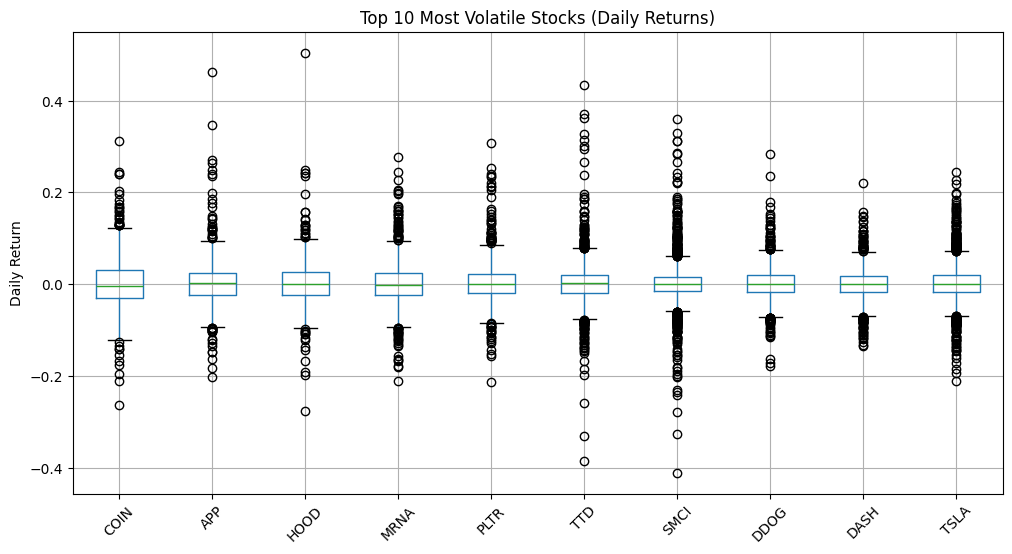

In [141]:
tickers_top10_vol = volatility.sort_values(ascending=False).head(10).index
top10_returns = daily_returns[tickers_top10_vol]

plt.figure(figsize=(12, 6))
top10_returns.boxplot()
plt.title("Top 10 Most Volatile Stocks (Daily Returns)")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.show()

These Top 10 most volatile stocks are concentrated in **high-growth** and **high-risk** industries. Several are **recent entrants to public markets**, which tend to be more volatile.


**Volume Spikes:**

In [142]:
avg_volume = data['Volume'].mean()
std_volume = data['Volume'].std()

volume_spikes = (data['Volume'] > (avg_volume + 3 * std_volume))
spike_counts = volume_spikes.sum(axis=1)
spike_days = spike_counts[spike_counts > 20] 
print(spike_days)

Date
2012-01-12     21
2012-01-17     24
2012-01-18     32
2012-01-19     30
2012-01-25     34
2012-01-26     35
2012-01-27     21
2012-01-31     27
2012-02-01     31
2012-02-02     25
2012-02-03     29
2012-02-09     23
2012-02-16     22
2012-02-29     26
2012-03-16     24
2012-04-10     22
2012-04-19     23
2012-04-24     21
2012-04-26     31
2012-04-27     27
2012-04-30     22
2012-05-01     22
2012-05-08     21
2012-05-17     34
2012-05-18     35
2012-05-22     22
2012-05-23     21
2012-05-31     33
2012-06-01     31
2012-06-06     21
2012-06-07     27
2012-06-22     47
2012-07-19     34
2012-07-20     36
2012-07-25     27
2012-07-26     32
2012-07-27     26
2012-08-01     22
2012-09-13     21
2012-09-14     24
2012-09-21     47
2012-10-17     22
2012-10-18     25
2012-10-19     22
2012-11-02     23
2012-11-30     24
2012-12-21     49
2013-01-31     24
2013-02-06     23
2013-04-25     28
2013-06-21     35
2013-06-28     32
2013-09-20     40
2013-10-24     21
2013-12-20     36
2014-

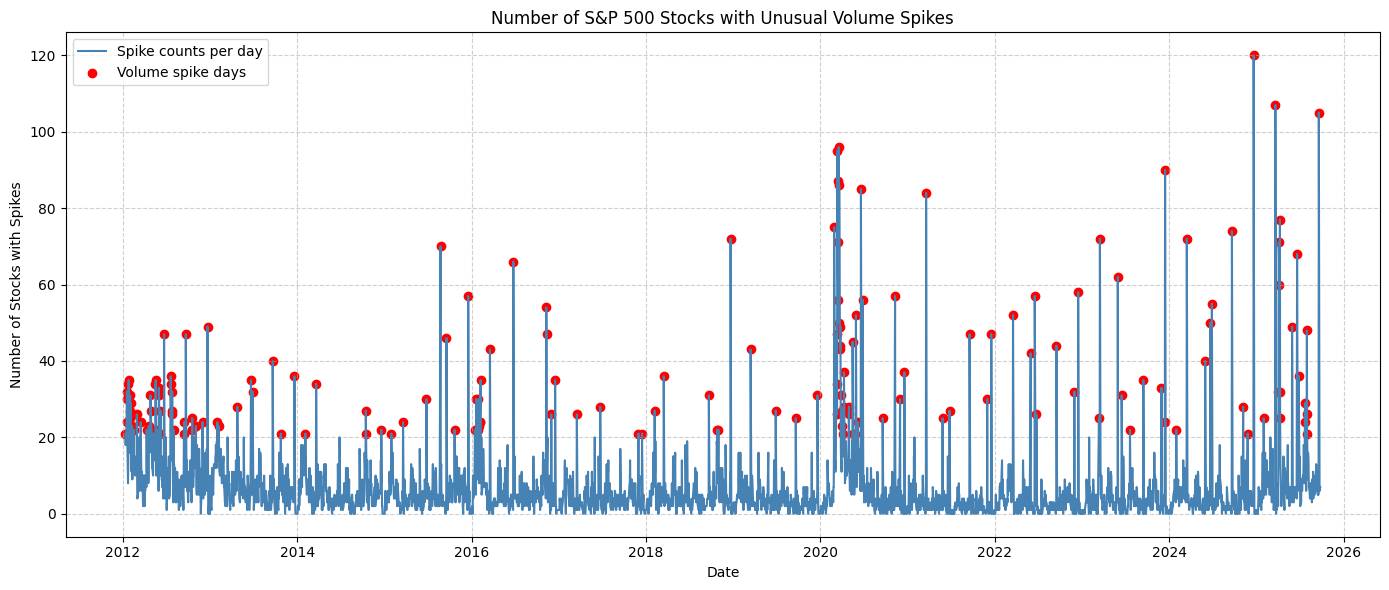

In [143]:
plt.figure(figsize=(14,6))
plt.plot(spike_counts.index, spike_counts.values, label="Spike counts per day", color="steelblue")

plt.scatter(spike_days.index, spike_days.values, color="red", label="Volume spike days")

plt.title("Number of S&P 500 Stocks with Unusual Volume Spikes")
plt.xlabel("Date")
plt.ylabel("Number of Stocks with Spikes")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

These dates correspond to periods when a large number of S&P 500 stocks experienced unusually high trading volumes, signaling episodes of broad market stress.

Examples include:
- Covid-19 outbreak (March 2020),
- Silicon Valley Bank collapse period (March 2023)